# Deadtime estimates (channel threshold)

Project 2D (channels, windows) into 1D using `x = channels * windows`, then fit `deadtime = m*x + b`.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2
from scipy.optimize import least_squares

sns.set_context('talk')

ROOT = Path.cwd().resolve().parent
EST_PATH = ROOT / 'data' / 'estimated_deadtime_10hz-12-22-25_full_channels.json'

with EST_PATH.open() as fh:
    estimates = json.load(fh)
est_df = pd.DataFrame(estimates)

print('Rows:', len(est_df))
print('Pulse rates:', sorted(est_df['pulse_rate_hz'].dropna().unique()))
print('Pulse counts:', sorted(est_df['num_pulses'].dropna().unique()))


Rows: 91
Pulse rates: [np.float64(10.0)]
Pulse counts: [np.int64(2)]


## Linear fit on projected axis


m = 1.347611 ± 0.000832 us per (channels*windows)
b = 2.776062 ± 0.176509 us
chi2 = 695035.01, dof = 89, chi2/dof = 7809.38, p = 0


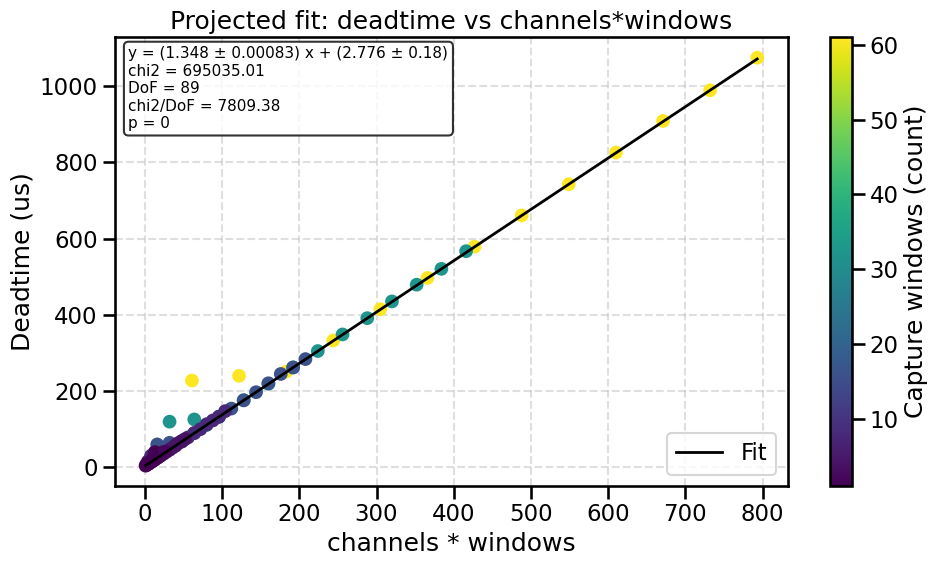

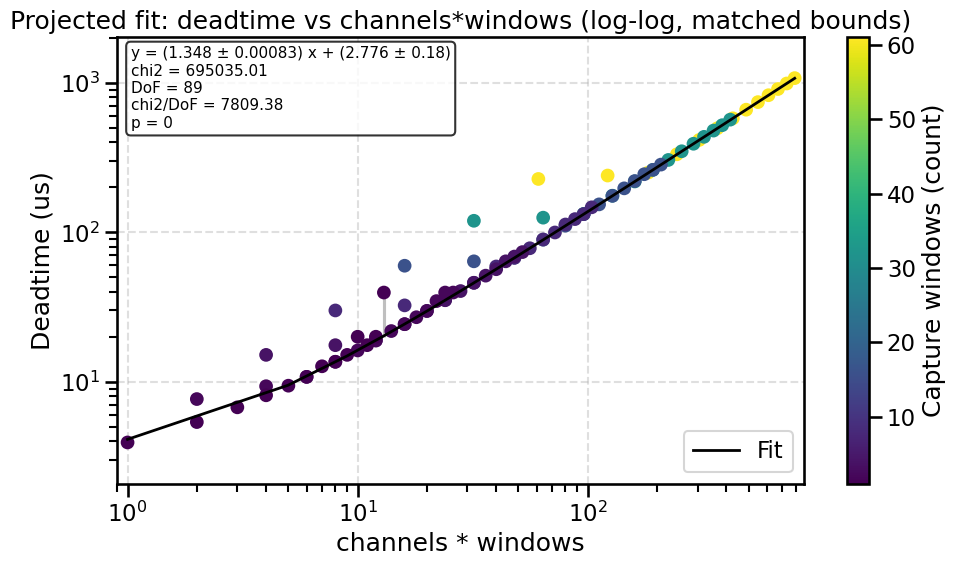

In [2]:
df = est_df.copy()
df = df.dropna(subset=['channel_count', 'windows', 'min_all_pulses_response_us'])
df = df[df['all_pulses_observed'] == True]

df['x'] = df['channel_count'] * df['windows']
df['y'] = df['min_all_pulses_response_us']
df['yerr_low'] = df['min_all_pulses_response_us'] - df['min_all_pulses_lower_bound_us']
df = df.dropna(subset=['yerr_low'])
df = df[df['yerr_low'] > 0]

x = df['x'].to_numpy(dtype=float)
y = df['y'].to_numpy(dtype=float)
yerr_low = df['yerr_low'].to_numpy(dtype=float)
yerr_high = np.full_like(y, 0.008)

def fit_asymmetric(x_vals, y_vals, err_low, err_high):
    def residuals(params):
        m, b = params
        resid = y_vals - (m * x_vals + b)
        sigma = np.where(resid >= 0, err_low, err_high)
        return resid / sigma

    m0, b0 = np.polyfit(x_vals, y_vals, 1)
    result = least_squares(residuals, x0=np.array([m0, b0]))
    m, b = result.x
    resid = y_vals - (m * x_vals + b)
    sigma = np.where(resid >= 0, err_low, err_high)
    chi2_val = np.sum((resid / sigma) ** 2)
    dof = len(y_vals) - 2
    p_val = chi2.sf(chi2_val, dof) if dof > 0 else float('nan')
    m_err = float('nan')
    b_err = float('nan')
    if result.jac.shape[0] >= result.jac.shape[1]:
        try:
            cov = np.linalg.inv(result.jac.T @ result.jac)
            if dof > 0:
                cov = cov * (chi2_val / dof)
            m_err, b_err = np.sqrt(np.diag(cov))
        except np.linalg.LinAlgError:
            pass
    return m, b, m_err, b_err, chi2_val, dof, p_val

m, b, m_err, b_err, chi2_val, dof, p_val = fit_asymmetric(x, y, yerr_low, yerr_high)
y_fit = m * x + b

print(f'm = {m:.6f} ± {m_err:.6f} us per (channels*windows)')
print(f'b = {b:.6f} ± {b_err:.6f} us')
print(f'chi2 = {chi2_val:.2f}, dof = {dof}, chi2/dof = {chi2_val / dof:.2f}, p = {p_val:.3g}')

plt.figure(figsize=(10, 6))
ax = plt.gca()
stats_text = (
    f'y = ({m:.4g} ± {m_err:.2g}) x + ({b:.4g} ± {b_err:.2g})\n'
    f'chi2 = {chi2_val:.2f}\nDoF = {dof}\nchi2/DoF = {chi2_val / dof:.2f}\np = {p_val:.3g}'
)
ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, ha='left', va='top', fontsize=11, bbox={'boxstyle': 'round,pad=0.3', 'facecolor': 'white', 'alpha': 0.8})

plt.errorbar(x, y, yerr=[yerr_low, yerr_high], fmt='none', ecolor='gray', alpha=0.5, zorder=1)
sc = plt.scatter(x, y, c=df['windows'], cmap='viridis', s=70, zorder=2)
x_line = np.linspace(x.min(), x.max(), 200)
plt.plot(x_line, m * x_line + b, color='black', linewidth=2, label='Fit')
cbar = plt.colorbar(sc)
cbar.set_label('Capture windows (count)')
plt.title('Projected fit: deadtime vs channels*windows')
plt.xlabel('channels * windows')
plt.ylabel('Deadtime (us)')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

# Log-scale plot
plt.figure(figsize=(10, 6))
ax = plt.gca()
ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, ha='left', va='top', fontsize=11, bbox={'boxstyle': 'round,pad=0.3', 'facecolor': 'white', 'alpha': 0.8})
plt.errorbar(x, y, yerr=[yerr_low, yerr_high], fmt='none', ecolor='gray', alpha=0.5, zorder=1)
sc = plt.scatter(x, y, c=df['windows'], cmap='viridis', s=70, zorder=2)
plt.plot(x_line, m * x_line + b, color='black', linewidth=2, label='Fit')
cbar = plt.colorbar(sc)
cbar.set_label('Capture windows (count)')
plt.xscale('log')
plt.yscale('log')
x_min, x_max = x.min() * 0.9, x.max() * 1.1
y_min, y_max = y.min() * 0.9, y.max() * 1.1
lx_min, lx_max = np.log10(x_min), np.log10(x_max)
ly_min, ly_max = np.log10(y_min), np.log10(y_max)
span = max(lx_max - lx_min, ly_max - ly_min)
lx_center = 0.5 * (lx_min + lx_max)
ly_center = 0.5 * (ly_min + ly_max)
ax.set_xlim(10 ** (lx_center - span / 2), 10 ** (lx_center + span / 2))
ax.set_ylim(10 ** (ly_center - span / 2), 10 ** (ly_center + span / 2))
plt.title('deadtime vs channels*windows (log-log)')
plt.xlabel('channels * windows')
plt.ylabel('Deadtime (us)')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


## Per-pulse fit (optional)


Pulses=2: m=1.347611 ± 0.000832, b=2.776062 ± 0.176509, chi2=695035.01, dof=89, p=0


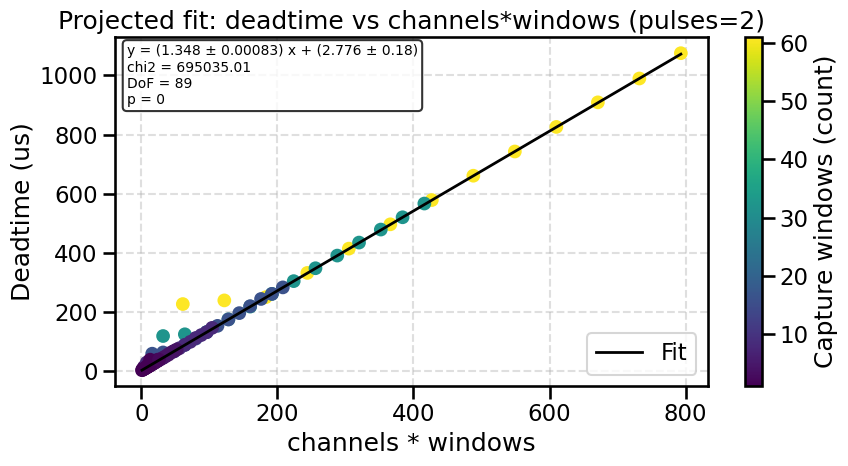

In [3]:
for pulse_count in sorted(df['num_pulses'].dropna().unique()):
    sub = df[df['num_pulses'] == pulse_count]
    if len(sub) < 3:
        continue
    x = sub['x'].to_numpy(dtype=float)
    y = sub['y'].to_numpy(dtype=float)
    yerr_low = sub['yerr_low'].to_numpy(dtype=float)
    yerr_high = np.full_like(y, 0.008)
    m, b, m_err, b_err, chi2_val, dof, p_val = fit_asymmetric(x, y, yerr_low, yerr_high)
    print(f'Pulses={int(pulse_count)}: m={m:.6f} ± {m_err:.6f}, b={b:.6f} ± {b_err:.6f}, chi2={chi2_val:.2f}, dof={dof}, p={p_val:.3g}')
    plt.figure(figsize=(9, 5))
    ax = plt.gca()
    stats_text = (
        f'y = ({m:.4g} ± {m_err:.2g}) x + ({b:.4g} ± {b_err:.2g})\n'
        f'chi2 = {chi2_val:.2f}\nDoF = {dof}\np = {p_val:.3g}'
    )
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, ha='left', va='top', fontsize=10, bbox={'boxstyle': 'round,pad=0.3', 'facecolor': 'white', 'alpha': 0.8})
    plt.errorbar(x, y, yerr=[yerr_low, yerr_high], fmt='none', ecolor='gray', alpha=0.5, zorder=1)
    sc = plt.scatter(x, y, c=sub['windows'], cmap='viridis', s=70, zorder=2)
    x_line = np.linspace(x.min(), x.max(), 200)
    plt.plot(x_line, m * x_line + b, color='black', linewidth=2, label='Fit')
    cbar = plt.colorbar(sc)
    cbar.set_label('Capture windows (count)')
    plt.title(f'Projected fit: deadtime vs channels*windows (pulses={int(pulse_count)})')
    plt.xlabel('channels * windows')
    plt.ylabel('Deadtime (us)')
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()
